In [1]:
import pandas as pd

In [2]:
data=pd.read_csv("diabetes2 (1).csv")

In [3]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


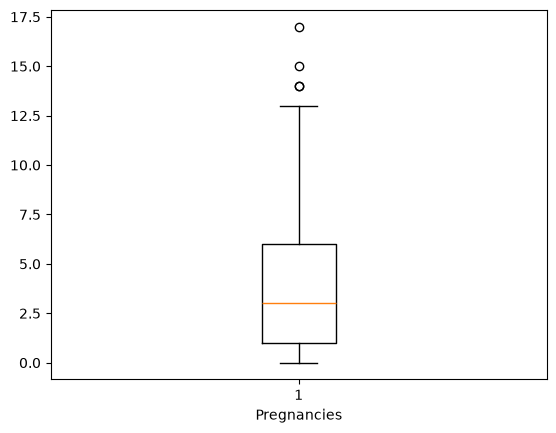

In [8]:
import matplotlib.pyplot as plt
plt.boxplot(data['Pregnancies'])
plt.xlabel('Pregnancies')
plt.show()

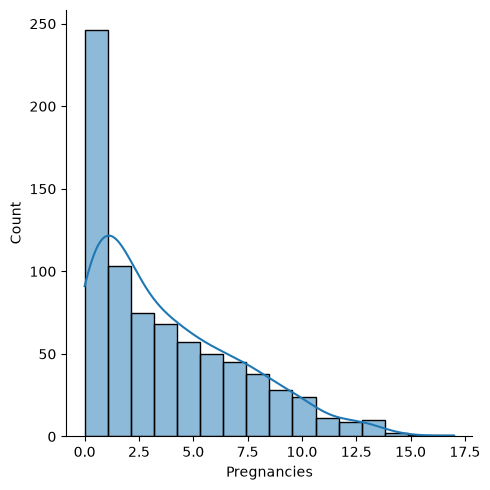

In [10]:
import seaborn as sns 
sns.displot(data['Pregnancies'],kde='True')

In [ ]:
#Options for Handling Outliers in Skewed Data
#--Winsorization (Capping)
#Instead of replacing with the median, cap values at a threshold (e.g., anything > 6 becomes 6).
#Preserves the order of values but trims extremes.
#Good if you want to keep the scale realistic but avoid distortion.

#--Log Transformation
#Apply np.log1p(Pregnancies) to reduce skewness.
#Keeps relative differences intact while compressing large values.
#Useful if your model assumes normality (like linear regression).

#--Binning / Categorization
#Convert pregnancies into bins:
#0 pregnancies
#1–3 (low)
#4–6 (moderate)
#6 (high)

#This way, you don’t lose information about women with many pregnancies, but you simplify the feature.
#Works well with tree-based models (Random Forest, XGBoost).

#--Robust Scaling
#Use RobustScaler from scikit-learn, which scales features using the median and IQR instead of mean and standard deviation.
#Automatically reduces the influence of outliers without replacing them.

#--Model-Specific Handling
#If you use tree-based models (Random Forest, Gradient Boosting), they are less sensitive to outliers. You might not need to modify the feature at all.
#If you use linear/logistic regression, handling skewness and outliers becomes more important.

#--Median replacement is safe and simple.
#--Winsorization keeps the feature realistic.
#--Log transform reduces skewness mathematically.
#--Binning captures risk levels without distortion.
#--RobustScaler is a modern, flexible option.

In [22]:
# for Pregnancies we used robustscalling
from sklearn.preprocessing import RobustScaler
re=RobustScaler()
data['Pregnancies']=re.fit_transform(data[['Pregnancies']])

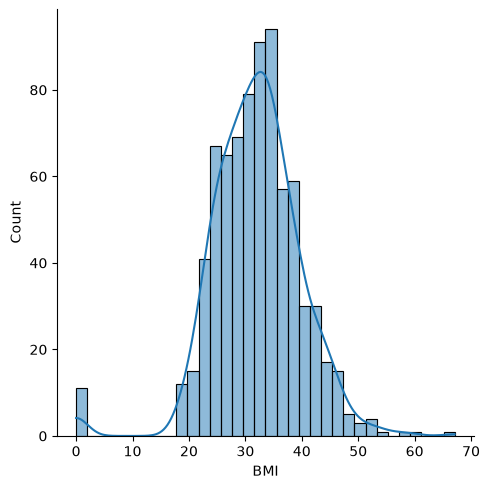

In [13]:
sns.displot(data['BMI'],kde='True')
plt.show()

In [23]:
#hear we use clip for BMI
data['BMI']=data['BMI'].clip(lower=20)

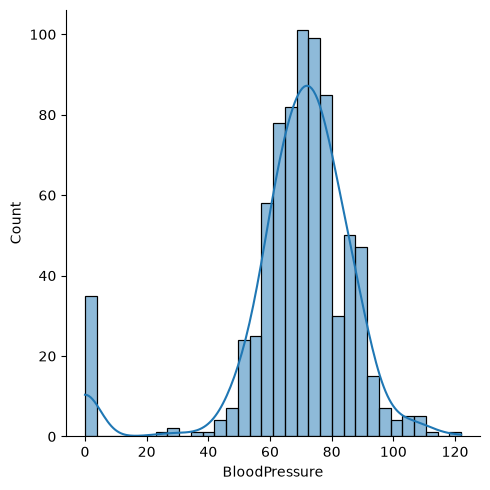

In [17]:
sns.displot(data['BloodPressure'],kde='True')
plt.show()

In [24]:
# hear we use clip for blood pressure
data['BloodPressure']=data['BloodPressure'].clip(lower=30)

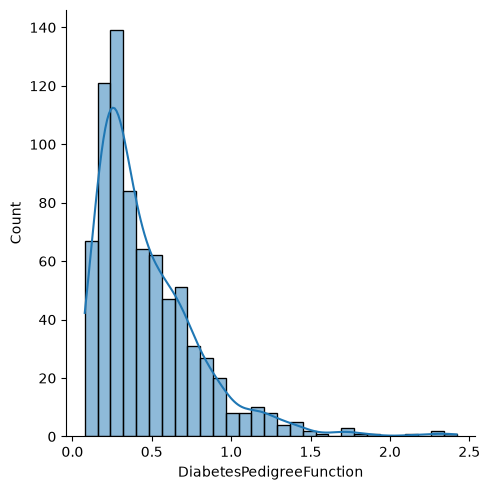

In [19]:
sns.displot(data['DiabetesPedigreeFunction'],kde='True')
plt.show()

In [20]:
# no outlier

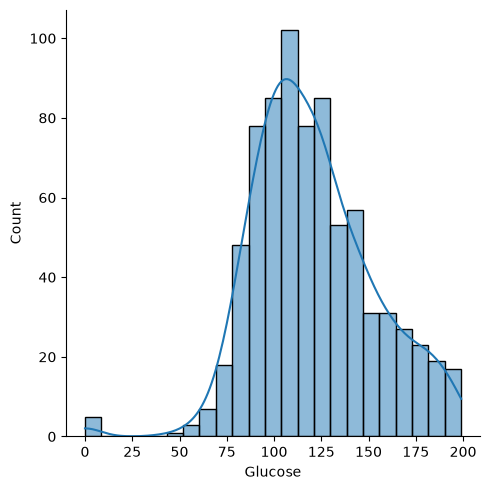

In [25]:
sns.displot(data['Glucose'],kde='True')
plt.show()

In [26]:
# we use cliper
data['Glucose']=data['Glucose'].clip(lower=30)

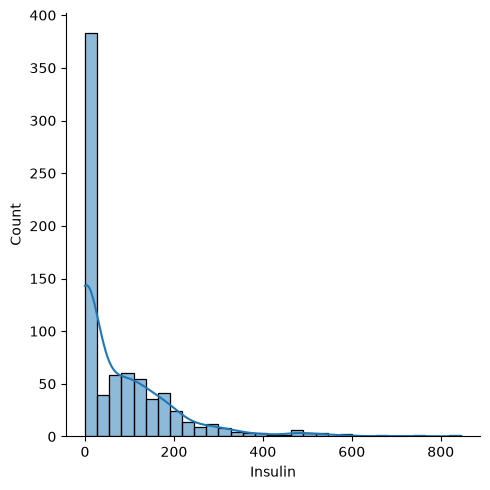

In [28]:
sns.displot(data['Insulin'],kde='True')
plt.show()

In [30]:
#use clip 
data['Insulin'] = data['Insulin'].clip(lower=15, upper=300)


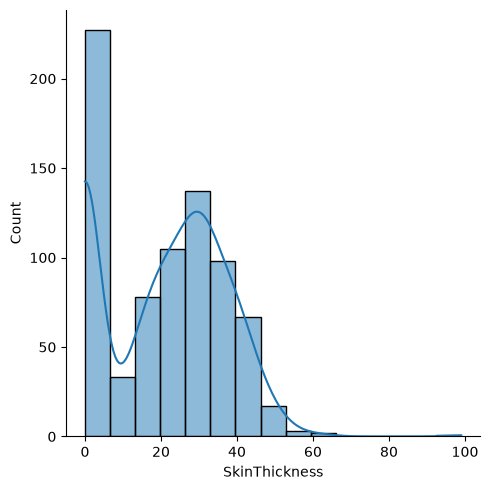

In [32]:
sns.displot(data['SkinThickness'],kde='True')
plt.show()

In [33]:
data['SkinThickness']=data['SkinThickness'].clip(lower=25)

In [34]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.6,148,72,35,15,33.6,0.627,50,1
1,-0.4,85,66,29,15,26.6,0.351,31,0
2,1.0,183,64,25,15,23.3,0.672,32,1
3,-0.4,89,66,25,94,28.1,0.167,21,0
4,-0.6,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,1.4,101,76,48,180,32.9,0.171,63,0
764,-0.2,122,70,27,15,36.8,0.340,27,0
765,0.4,121,72,25,112,26.2,0.245,30,0
766,-0.4,126,60,25,15,30.1,0.349,47,1


In [36]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
data['Age']=sc.fit_transform(data[['Age']])
data['BMI']=sc.fit_transform(data[['BMI']])
data['BloodPressure']=sc.fit_transform(data[['BloodPressure']])
data['Glucose']=sc.fit_transform(data[['Glucose']])
data['Insulin']=sc.fit_transform(data[['Insulin']])
data['SkinThickness']=sc.fit_transform(data[['SkinThickness']])

In [37]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.6,0.859827,0.101604,0.746863,-0.760056,0.186552,0.627,1.425995,1
1,-0.4,-1.153134,-0.299587,-0.082025,-0.760056,-0.813350,0.351,-0.190672,0
2,1.0,1.978138,-0.433317,-0.634618,-0.760056,-1.284732,0.672,-0.105584,1
3,-0.4,-1.025327,-0.299587,-0.634618,0.162079,-0.599085,0.167,-1.041549,0
4,-0.6,0.508357,-2.038081,0.746863,1.025850,1.543560,2.288,-0.020496,1
...,...,...,...,...,...,...,...,...,...
763,1.4,-0.641906,0.369064,2.542788,1.165921,0.086561,0.171,2.532136,0
764,-0.2,0.029081,-0.032127,-0.358322,-0.760056,0.643649,0.340,-0.531023,0
765,0.4,-0.002871,0.101604,-0.634618,0.372185,-0.870487,0.245,-0.275760,0
766,-0.4,0.156888,-0.700778,-0.634618,-0.760056,-0.313399,0.349,1.170732,1


In [56]:
x=data.drop(data['Outcome'])
y=data['Outcome']
y=y.drop(y.index[765:766])

In [60]:
y=y.drop(767)

In [61]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [62]:
x.shape

(766, 9)

In [63]:
y.shape

(766,)

In [64]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.97      0.78       100
           1       0.50      0.06      0.10        54

    accuracy                           0.65       154
   macro avg       0.58      0.51      0.44       154
weighted avg       0.60      0.65      0.54       154



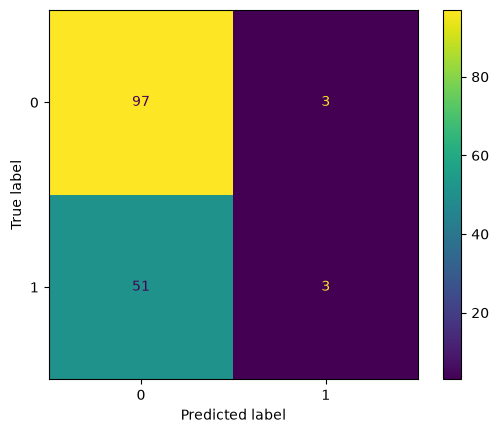

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [71]:
lr.score(x_train,y_train)

0.6601307189542484

In [72]:
lr.score(x_test,y_test)

0.6493506493506493